## 0. Load the libraries

In [84]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import seaborn as sns
import numpy as np
import io
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import KNNImputer
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.multioutput import MultiOutputRegressor
import lightgbm as lgb
from tqdm import tqdm
import time
import json
import pickle

# 1. Retrieve Sets



In [67]:
# Load CSV files and convert to NumPy arrays
X_train_scaled = pd.read_csv('../results/X_train_scaled.csv').values
y_train = pd.read_csv('../results/y_train.csv').values.ravel()  # Ensure it's a 1D array

X_val_scaled = pd.read_csv('../results/X_val_scaled.csv').values
y_val = pd.read_csv('../results/y_val.csv').values.ravel()

X_test_scaled = pd.read_csv('../results/X_test_scaled.csv').values
y_test = pd.read_csv('../results/y_test.csv').values.ravel()

# Load Full Train, Validation, and Test Sets
X_train_full_scaled = pd.read_csv('../results/X_train_full_scaled.csv').values
y_train_full = pd.read_csv('../results/y_train_full.csv').values

X_val_full_scaled = pd.read_csv('../results/X_val_full_scaled.csv').values
y_val_full = pd.read_csv('../results/y_val_full.csv').values

X_test_full_scaled = pd.read_csv('../results/X_test_full_scaled.csv').values
y_test_full = pd.read_csv('../results/y_test_full.csv').values

input_features = pd.read_csv('../results/input_features.csv')['input_features'].tolist()
target_features = pd.read_csv('../results/target_features.csv')['target_features'].tolist()

In [16]:
X_train_scaled

array([[-0.59631901, -0.34413163, -0.66585497, ..., -1.4118611 ,
        -1.4611563 , -1.4450898 ],
       [-1.07856432, -1.14888265, -1.42070037, ..., -1.31966561,
        -1.3204422 , -1.236868  ],
       [-0.70592021, -0.97488243, -1.08521352, ..., -1.52454448,
        -1.34389455, -1.04166006],
       ...,
       [-0.64015949, -0.53988188, -0.56101533, ...,  0.22716981,
         0.16878195,  0.07753211],
       [-1.21008576, -0.86613229, -1.0642456 , ...,  0.07351066,
         0.01634168, -0.06562038],
       [-0.50863804, -0.03963125, -0.12068884, ...,  1.13888075,
         0.88407859,  0.52000343]])

In [10]:
y_train

0         6.2
1        -3.2
2        -1.1
3         7.4
4         6.0
         ... 
29935     9.0
29936    18.7
29937    13.6
29938    13.0
29939    18.0
Name: temperature_max_target_21, Length: 29940, dtype: float64

# 2. Train the model
## 2.1 For one target


In [17]:
# Define LightGBM parameters
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',  # Gradient Boosting Decision Trees
    'num_leaves': 31,         # Maximum number of leaves in one tree
    'learning_rate': 0.05,    # Shrinkage rate
    'feature_fraction': 0.8,  # Proportion of features used per iteration
    'verbosity': -1           # Suppress logs
}

In [18]:
# Initialize the LightGBM regressor
model = LGBMRegressor(**params, n_estimators=500)

# Training with Progress Bar
print("[INFO] Training LightGBM model...")
start_time = time.time()

# Fit the model with progress bar
model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)],
    eval_metric='rmse',
)

end_time = time.time()
print(f"[INFO] Training completed in {end_time - start_time:.2f} seconds.")

[INFO] Training LightGBM model...
[INFO] Training completed in 2.09 seconds.



## 2.2 Predictions for one target

In [21]:
# Make predictions on the test set
print("[INFO] Making predictions...")
y_pred = model.predict(X_val_scaled)

# Evaluate the model
print("[INFO] Evaluating the model...")
rmse = mean_squared_error(y_val, y_pred, squared=False)
mae = mean_absolute_error(y_val, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

[INFO] Making predictions...
[INFO] Evaluating the model...
RMSE: 5.63
MAE: 4.52


c:\Users\Мария\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


## 3. Hyperparameter optimization

In [22]:
# Parameter grid for GridSearchCV
param_grid = {
    'num_leaves': [31, 64],
    'learning_rate': [0.01, 0.05],
    'min_data_in_leaf': [10, 20],
    'max_depth': [-1, 5, 10]
}

# Initialize the LightGBM model
lgb_model = LGBMRegressor(n_estimators=500, **params)

# GridSearchCV with RMSE scoring
grid_search = GridSearchCV(lgb_model, param_grid, cv=3, scoring='neg_root_mean_squared_error', verbose=0)
grid_search.fit(X_train_scaled, y_train)

# Print the best parameters
print(f"Best Parameters: {grid_search.best_params_}")


Best Parameters: {'learning_rate': 0.01, 'max_depth': 5, 'min_data_in_leaf': 10, 'num_leaves': 64}


In [68]:
# Define LightGBM parameters
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',  # Gradient Boosting Decision Trees
    'num_leaves': 64,         # Maximum number of leaves in one tree
    'learning_rate': 0.01,    # Shrinkage rate
    'feature_fraction': 0.8,  # Proportion of features used per iteration
    'max_depth': 5,
    'min_data_in_leaf': 10,
    'verbosity': -1           # Suppress logs
}

In [24]:
# Initialize the LightGBM regressor
model = LGBMRegressor(**params, n_estimators=500)

start_time = time.time()

# Fit the model with progress bar
model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)],
    eval_metric='rmse',
)

end_time = time.time()
print(f"[INFO] Training completed in {end_time - start_time:.2f} seconds.")

[INFO] Training completed in 1.93 seconds.


In [25]:
# Make predictions on the validation set
print("[INFO] Making predictions...")
y_pred = model.predict(X_val_scaled)

# Evaluate the model
print("[INFO] Evaluating the model...")
rmse = mean_squared_error(y_val, y_pred, squared=False)
mae = mean_absolute_error(y_val, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

[INFO] Making predictions...
[INFO] Evaluating the model...
RMSE: 5.26
MAE: 4.23


c:\Users\Мария\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [26]:
# Make predictions on the test set
print("[INFO] Making predictions...")
y_pred = model.predict(X_test_scaled)

# Evaluate the model
print("[INFO] Evaluating the model...")
rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

[INFO] Making predictions...
[INFO] Evaluating the model...
RMSE: 5.01
MAE: 3.97


c:\Users\Мария\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


## 4. Feature Importance

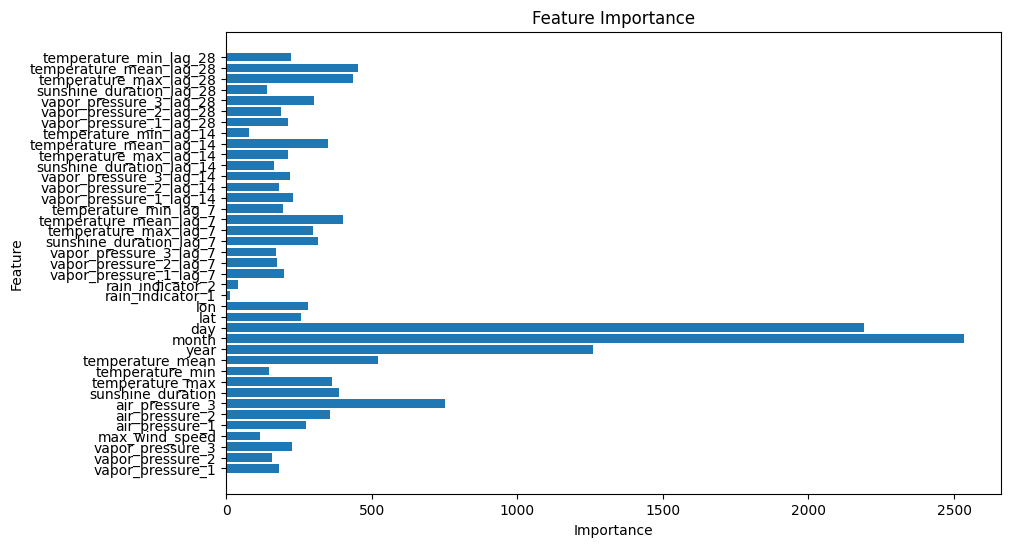

In [30]:
plt.figure(figsize=(10, 6))
plt.barh(input_features, model.feature_importances_)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [38]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=input_features)
X_val_scaled_df = pd.DataFrame(X_val_scaled, columns=input_features)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=input_features)

In [40]:
# Initialize the LightGBM regressor
model = LGBMRegressor(**params, n_estimators=500)

# Training with Progress Bar
print("[INFO] Training LightGBM model...")
start_time = time.time()

# Fit the model with progress bar
model.fit(
    X_train_scaled_df.drop(['rain_indicator_1', 'rain_indicator_2'], axis=1), y_train,
    eval_set=[(X_val_scaled_df.drop(['rain_indicator_1', 'rain_indicator_2'], axis=1), y_val)],
    eval_metric='rmse',
)

end_time = time.time()
print(f"[INFO] Training completed in {end_time - start_time:.2f} seconds.")

[INFO] Training LightGBM model...
[INFO] Training completed in 1.88 seconds.


In [41]:
# Make predictions on the validation set
print("[INFO] Making predictions...")
y_pred = model.predict(X_val_scaled_df.drop(['rain_indicator_1', 'rain_indicator_2'], axis=1))

# Evaluate the model
print("[INFO] Evaluating the model...")
rmse = mean_squared_error(y_val, y_pred, squared=False)
mae = mean_absolute_error(y_val, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

[INFO] Making predictions...
[INFO] Evaluating the model...
RMSE: 5.24
MAE: 4.21


c:\Users\Мария\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [43]:
# Make predictions on the test set
print("[INFO] Making predictions...")
y_pred = model.predict(X_test_scaled_df.drop(['rain_indicator_1', 'rain_indicator_2'], axis=1))

# Evaluate the model
print("[INFO] Evaluating the model...")
rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

[INFO] Making predictions...
[INFO] Evaluating the model...
RMSE: 5.02
MAE: 3.97


c:\Users\Мария\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


## 5. Models for all targets

In [73]:
X_train_full_scaled_df = pd.DataFrame(X_train_full_scaled, columns=input_features)
X_val_full_scaled_df = pd.DataFrame(X_val_full_scaled, columns=input_features)
X_test_full_scaled_df = pd.DataFrame(X_test_full_scaled, columns=input_features)

y_train_full_df = pd.DataFrame(y_train_full, columns=target_features)
y_val_full_df = pd.DataFrame(y_val_full, columns=target_features)
y_test_full_df = pd.DataFrame(y_test_full, columns=target_features)

In [74]:
print(X_train_full_scaled_df.shape, X_val_full_scaled_df.shape, X_test_full_scaled_df.shape)

(29940, 39) (8850, 39) (8880, 39)


In [ ]:
# Drop rain indicators since they are not so important
X_train_full_scaled_df = X_train_full_scaled_df.drop(['rain_indicator_1', 'rain_indicator_2'], axis=1)
X_val_full_scaled_df = X_val_full_scaled_df.drop(['rain_indicator_1', 'rain_indicator_2'], axis=1)
X_test_full_scaled_df = X_test_full_scaled_df.drop(['rain_indicator_1', 'rain_indicator_2'], axis=1)

In [88]:
# Ensure latitude and longitude are preserved
locations = pd.read_csv('../data/distributed_stations.csv')[['lat','lon']] 

# Initialize results storage
results = []

# Loop through each target feature
for target in target_features:
    print(f"[INFO] Training for Target: {target}...")

    # Prepare LightGBM datasets
    lgb_train = lgb.Dataset(X_train_full_scaled_df, y_train_full_df[target])
    lgb_test = lgb.Dataset(X_val_full_scaled_df, y_val_full_df[target], reference=lgb_train)

    # Define model parameters
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'learning_rate': 0.05,
        'num_leaves': 64,
        'max_depth': -1,
        'min_data_in_leaf': 20,
        'bagging_fraction': 0.8,
        'feature_fraction': 0.8,
        'verbose': -1
    }

    # Track progress
    print("[INFO] Training LightGBM model...")
    start_time = time.time()
    progress_bar = tqdm(total=500, desc=f"Training Progress for {target}", unit="iteration")

    # Train the LightGBM model
    model = lgb.train(
        params,
        lgb_train,
        num_boost_round=500,
        valid_sets=[lgb_train, lgb_test],
        valid_names=['train', 'valid'],
        callbacks=[lambda env: progress_bar.update(1)]
    )

    progress_bar.close()
    end_time = time.time()
    print(f"[INFO] Training completed in {end_time - start_time:.2f} seconds for Target: {target}.")

    # Calculate predictions
    y_pred = model.predict(X_test_full_scaled_df)

    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test_full_df[target], y_pred))
    mae = mean_absolute_error(y_test_full_df[target], y_pred)
    bias = np.mean(y_pred - y_test_full_df[target])

    print(f"[RESULTS] RMSE: {rmse:.4f}, MAE: {mae:.4f}, Bias: {bias:.4f}")

    # Store results with predictions and locations
    results.append({
        'Target': target,
        'RMSE': rmse,
        'MAE': mae,
        'Bias': bias,
        'Predictions': json.dumps(y_pred.tolist()),
        'Ground Truth': json.dumps(y_test_full_df[target].tolist()),
        'Latitude': json.dumps(locations['lat'].values.tolist()),
        'Longitude': json.dumps(locations['lon'].values.tolist())
    })

# Save results to a DataFrame
results_df = pd.DataFrame(results)
results_df.to_csv('../results/results_with_metrics.csv', index=False)


print("[INFO] All models trained and results saved.")

[INFO] Training for Target: temperature_max_target_21...
[INFO] Training LightGBM model...


Training Progress for temperature_max_target_21: 100%|██████████| 500/500 [00:05<00:00, 90.33iteration/s] 


[INFO] Training completed in 5.54 seconds for Target: temperature_max_target_21.
[RESULTS] RMSE: 5.3160, MAE: 4.1843, Bias: 0.3135
[INFO] Training for Target: temperature_max_target_22...
[INFO] Training LightGBM model...


Training Progress for temperature_max_target_22: 100%|██████████| 500/500 [00:06<00:00, 71.55iteration/s] 


[INFO] Training completed in 6.99 seconds for Target: temperature_max_target_22.
[RESULTS] RMSE: 5.3180, MAE: 4.1705, Bias: 0.4171
[INFO] Training for Target: temperature_max_target_23...
[INFO] Training LightGBM model...


...

[INFO] Training completed in 4.09 seconds for Target: temperature_mean_target_33.
[RESULTS] RMSE: 4.2861, MAE: 3.2832, Bias: 0.1434
[INFO] Training for Target: temperature_mean_target_34...
[INFO] Training LightGBM model...


Training Progress for temperature_mean_target_34: 100%|██████████| 500/500 [00:04<00:00, 114.26iteration/s]


[INFO] Training completed in 4.38 seconds for Target: temperature_mean_target_34.
[RESULTS] RMSE: 4.2517, MAE: 3.2838, Bias: 0.1902
[INFO] Training for Target: temperature_mean_target_35...
[INFO] Training LightGBM model...


Training Progress for temperature_mean_target_35: 100%|██████████| 500/500 [00:05<00:00, 93.49iteration/s] 


[INFO] Training completed in 5.35 seconds for Target: temperature_mean_target_35.
[RESULTS] RMSE: 4.2442, MAE: 3.3275, Bias: 0.1703
[INFO] All models trained and results saved.
